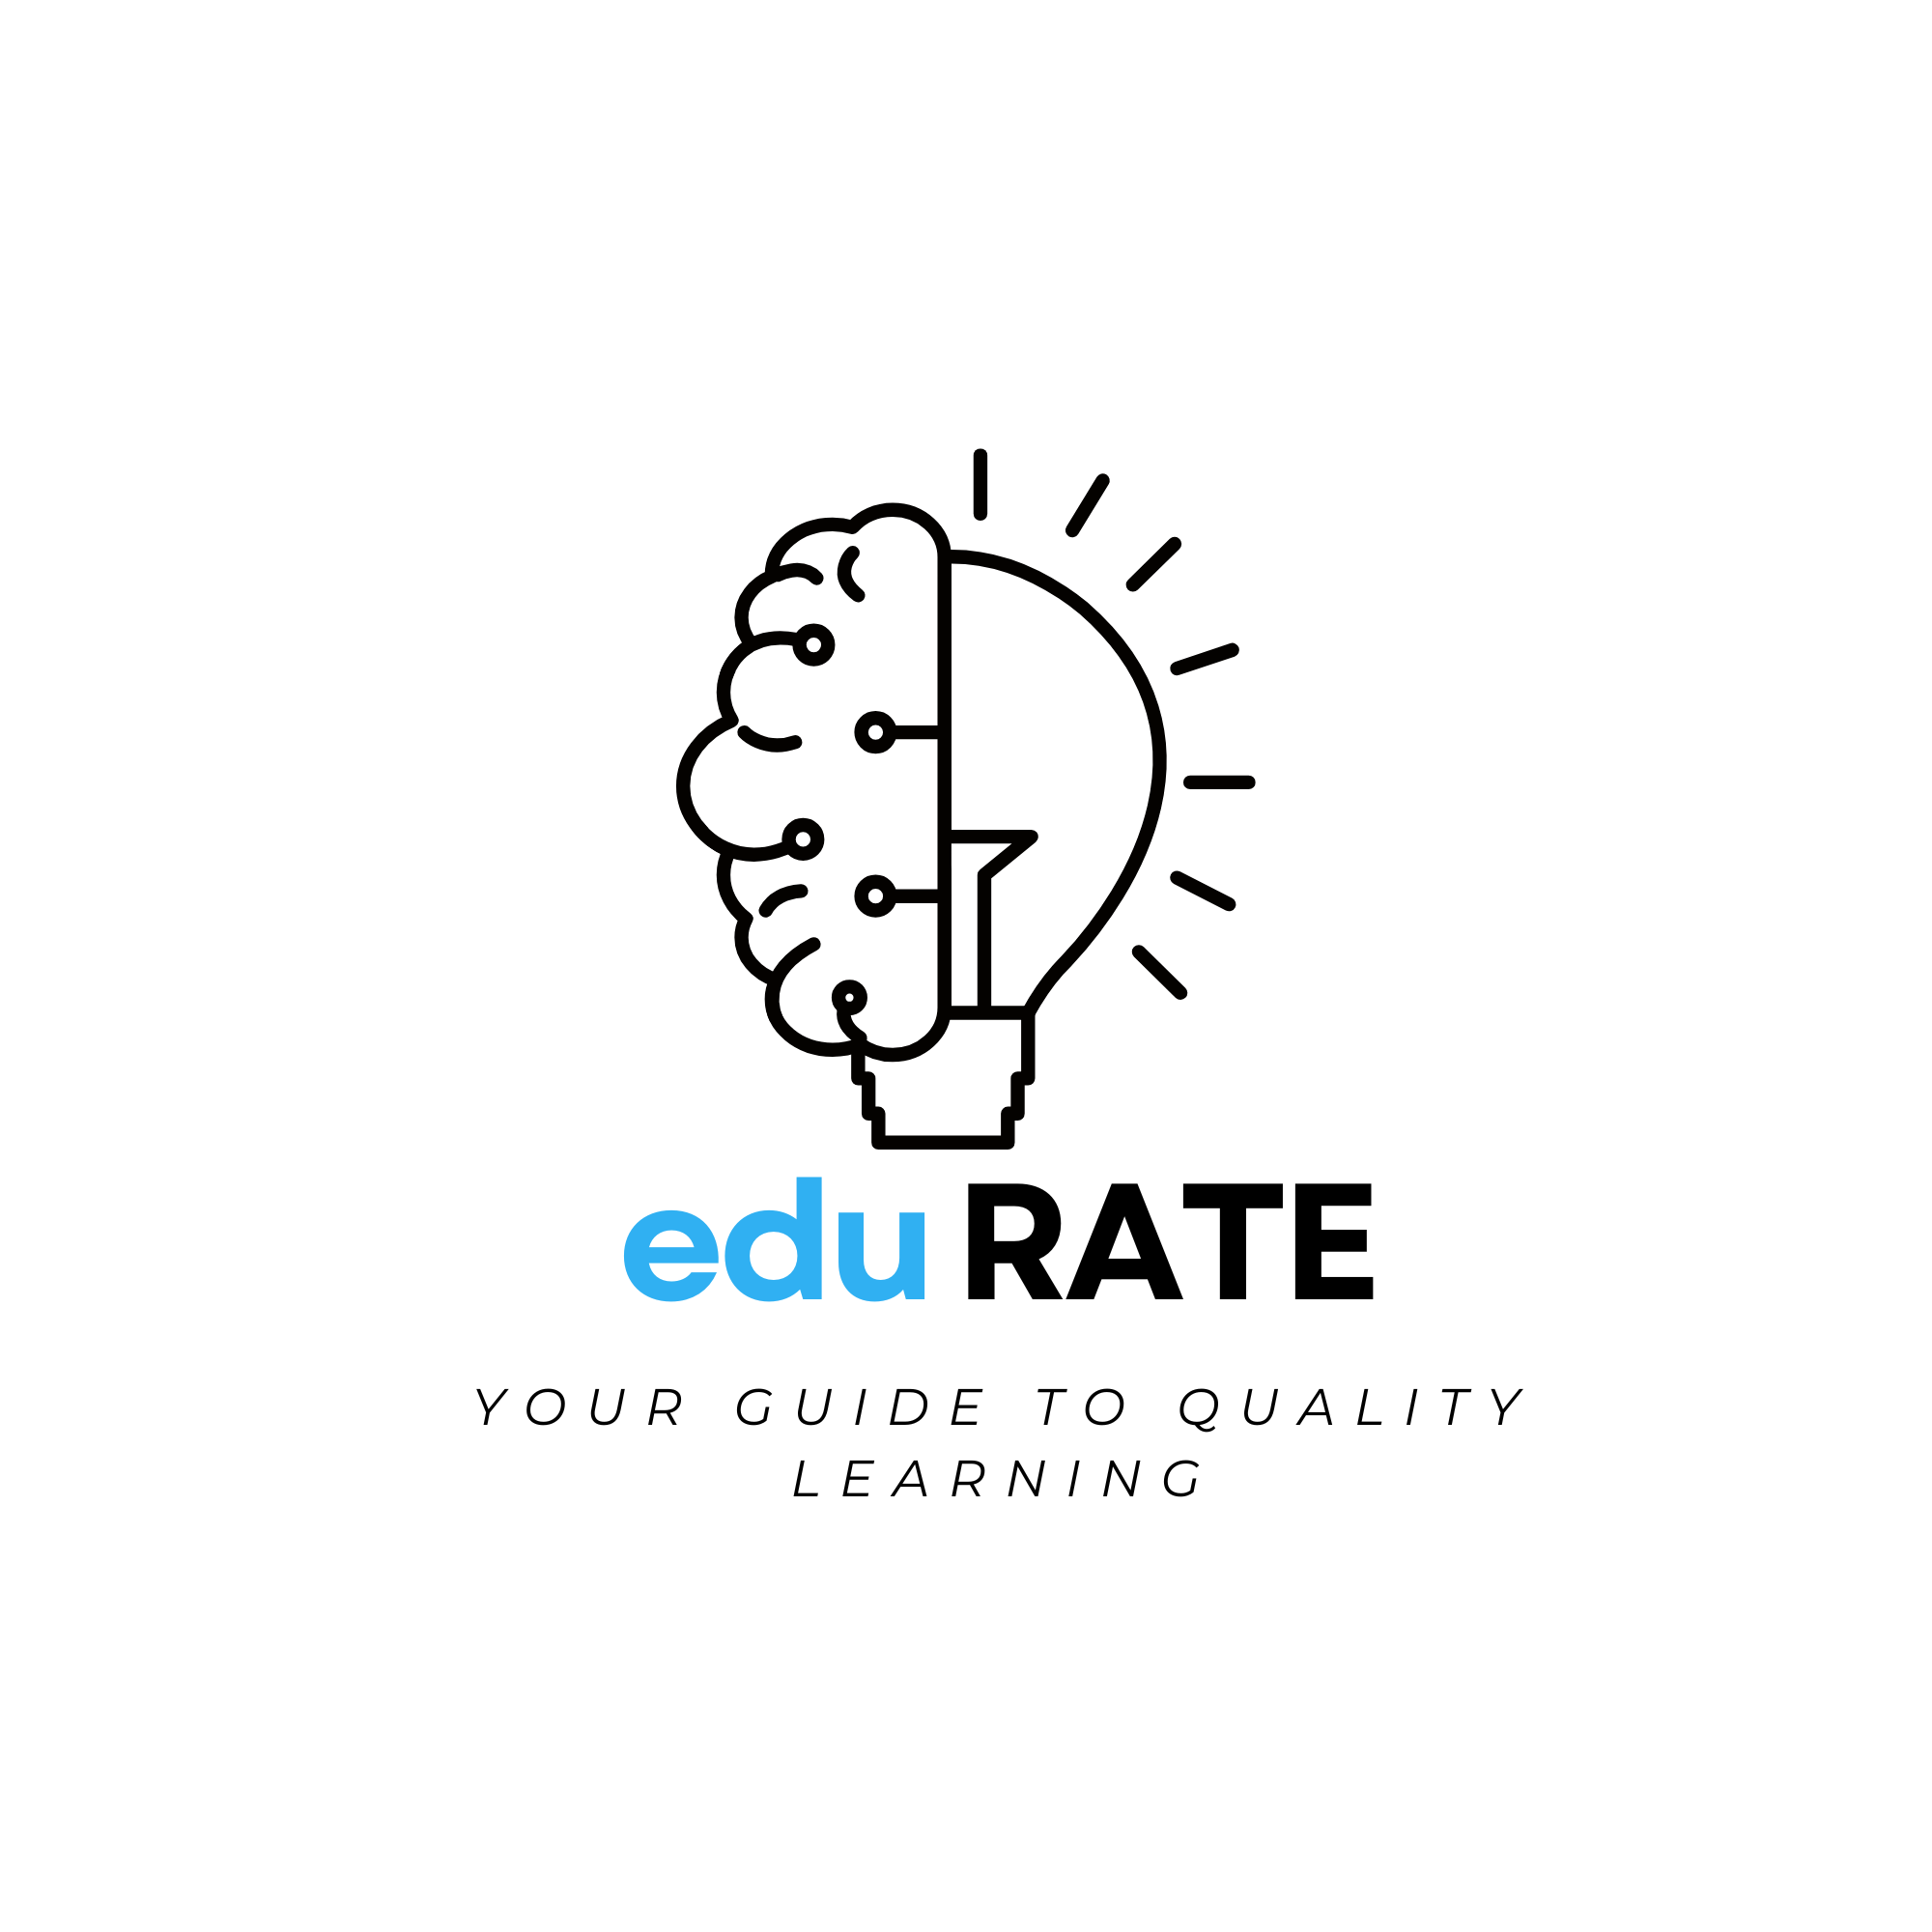

**Sentiment Analysis Feature**

In [1]:
'''
Description For This Feature:
This notebook is for developing the sentiment analysis feature for edu Rate project
The sentiment analysis feature will be used to read written student reviews and establish the tone of emotion in the written review. The system accepts review text as input, and then applies natural language processing techniques to categorize each review as either positive, negative or neutral. A sentiment label is the output of this feature, and optionally a sentiment score or summarized insight that represents the overall opinion. This feature allows one to get an overview about the overall sentiment about a university, course or professor without having to go through the reviews individually. This classification must be done automatically and efficiently in near real-time by the system at an acceptable level of accuracy. This feature converts unstructured textual data into valuable insights that can aid in making superior decisions among students.
'''

'\nDescription For This Feature:\nThis notebook is for developing the sentiment analysis feature for edu Rate project\nThe sentiment analysis feature will be used to read written student reviews and establish the tone of emotion in the written review. The system accepts review text as input, and then applies natural language processing techniques to categorize each review as either positive, negative or neutral. A sentiment label is the output of this feature, and optionally a sentiment score or summarized insight that represents the overall opinion. This feature allows one to get an overview about the overall sentiment about a university, course or professor without having to go through the reviews individually. This classification must be done automatically and efficiently in near real-time by the system at an acceptable level of accuracy. This feature converts unstructured textual data into valuable insights that can aid in making superior decisions among students.\n'

# Importing Neccessary Libraries

In [2]:
# Libraries For Data Handling
import pandas as pd
import numpy as np
# Libraries For Data Visualization
import matplotlib.pyplot as plt
# Libraries For NLP Processing
import re
import string
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
# Libraires For ML
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
# Libraries To Save The Models For Deployment Purposes And Later Use
import pickle
# Other Libraries
from transformers import (
    BertTokenizer,
    BertForSequenceClassification,
    Trainer,
    TrainingArguments
)
import torch

In [3]:
# Onetime Setup For Donwnloading Needed Packages
nltk.download('punkt')
nltk.download('stopwords')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


True

# Data Collection

In [4]:
# Reading the dataset and print the five records of the dataset
df = pd.read_csv('/content/reviews.csv')
df.head()

,Id,Review,Label
0,0,good and interesting,5
1,1,"This class is very helpful to me. Currently, I...",5
2,2,like!Prof and TAs are helpful and the discussi...,5
3,3,Easy to follow and includes a lot basic and im...,5
4,4,Really nice teacher!I could got the point eazl...,4


# Exploratory Data Analysis (EDA)

In [5]:
# Check for the first 10 records from the dataset
df.head(10)

,Id,Review,Label
0,0,good and interesting,5
1,1,"This class is very helpful to me. Currently, I...",5
2,2,like!Prof and TAs are helpful and the discussi...,5
3,3,Easy to follow and includes a lot basic and im...,5
4,4,Really nice teacher!I could got the point eazl...,4
5,5,"Great course - I recommend it for all, especia...",5
6,6,One of the most useful course on IT Management!,5
7,7,I was disappointed because the name is mislead...,3
8,8,Super content. I'll definitely re-do the course,5
9,9,One of the excellent courses at Coursera for i...,5


In [6]:
# Check for the last 10 records from the dataset
df.tail(10)

,Id,Review,Label
107008,107008,The great course. I hope that prof. Brook we c...,5
107009,107009,Excellent course!Will use information to help ...,5
107010,107010,"For those interested in taking exams, these qu...",2
107011,107011,This course is awesome. It introduce the Zika ...,5
107012,107012,"Great, clear, concise, explanations on everyth...",5
107013,107013,Trendy topic with talks from expertises in the...,4
107014,107014,"Wonderful! Simple and clear language, good ins...",5
107015,107015,an interesting and fun course. thanks. dr quincy,5
107016,107016,"very broad perspective, up to date information...",4
107017,107017,An informative course on the social and financ...,4


In [7]:
# Check for the format of the columns
df.dtypes

,0
Id,int64
Review,object
Label,int64


In [8]:
# Check for the name of the existed columns
df.columns

Index(['Id', 'Review', 'Label'], dtype='object')

In [9]:
# Check for the size of the dataset
df.shape

(107018, 3)

In [10]:
# Check for general information about the dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 107018 entries, 0 to 107017
Data columns (total 3 columns):
 #   Column  Non-Null Count   Dtype 
---  ------  --------------   ----- 
 0   Id      107018 non-null  int64 
 1   Review  107018 non-null  object
 2   Label   107018 non-null  int64 
dtypes: int64(2), object(1)
memory usage: 2.4+ MB


In [11]:
# Check the missing data
missing_data = df.isnull().sum()
print(missing_data)

Id        0
Review    0
Label     0
dtype: int64


In [12]:
# Check the duplicated data
duplicated_data = df.duplicated().sum()
print(duplicated_data)

0


In [13]:
# Check for the distribution of the data
df['Label'].value_counts().sort_index()

,count
Label,
1,2469
2,2251
3,5071
4,18054
5,79173


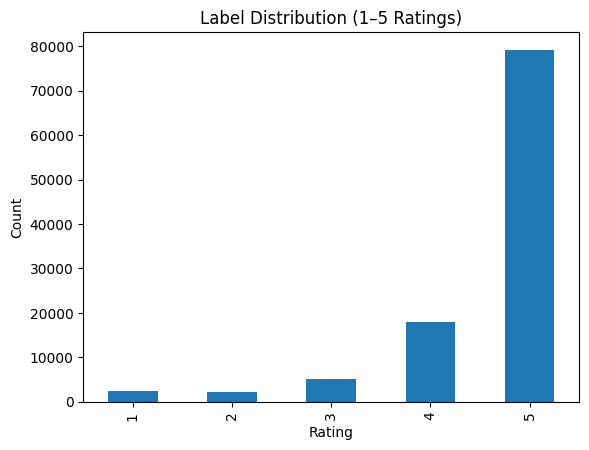

In [14]:
# a Visual for the distibution of the label column
df['Label'].value_counts().sort_index().plot(kind='bar')
plt.title("Label Distribution (1–5 Ratings)")
plt.xlabel("Rating")
plt.ylabel("Count")
plt.show()

# Data Processing

In [15]:
# Mapping Function for the labels to convert them from ratings (1-5) into (negative/neutral/positive)
def mapping_for_label(x):
    if x <= 2:
        return "negative"
    elif x == 3:
        return "neutral"
    else:
        return "positive"

In [16]:
# Apply the mapping function
df['sentiment_label'] = df['Label'].apply(mapping_for_label)

In [17]:
# Cleaning text function
def cleaning_textReviews(text):
    text = str(text).lower()                  # To make the reviews into lowercase
    text = re.sub(r'[^\w\s]', '', text)       # To remove punctuation on the reviews
    text = re.sub(r'\d+', '', text)           # To remove numbers on the reviews
    text = re.sub(r'\s+', ' ', text).strip()  # To remove the spaces on the reviews
    return text

In [18]:
# Apply the cleaning text function
df['clean_text_review'] = df['Review'].apply(cleaning_textReviews)

In [19]:
# Mapping for the sentiment label for model training
mapping_label = {
    "negative": 0,
    "neutral": 1,
    "positive": 2
}
df['encoded_sentiment_label'] = df['sentiment_label'].map(mapping_label)

# Model Development

In [20]:
# Split the dataset for feature and label
x = df['clean_text_review']
y = df['encoded_sentiment_label']

In [21]:
# Split for training and testing
x_train, x_test, y_train, y_test = train_test_split (x, y, test_size=0.2, random_state=42, stratify=y)

In [22]:
# Load the bert pre-trained model
tokenizer = BertTokenizer.from_pretrained("bert-base-uncased")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

In [23]:
# Now we will use Bert Model for tokenization and model training
tokenized_train = tokenizer(list(x_train), truncation=True, padding=True, max_length=128)
tokenized_test = tokenizer(list(x_test), truncation=True, padding=True, max_length=128)

In [24]:
# Now we will build a custom dataset for the model training
class training_sentiment_data(torch.utils.data.Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = labels.tolist()
    def __getitem__(self, idx):
        item = {key: torch.tensor(val[idx]) for key, val in self.encodings.items()}
        item["labels"] = torch.tensor(self.labels[idx])
        return item
    def __len__(self):
        return len(self.labels)

In [25]:
# Creating an instance from the custom dataset
training_dataset = training_sentiment_data(tokenized_train, y_train)
testing_dataset = training_sentiment_data(tokenized_test, y_test)

In [26]:
# Now after data embedding and representation using bert, now we need to start with loading bert model for classification
model = BertForSequenceClassification.from_pretrained("bert-base-uncased", num_labels=3)

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [27]:
# Configure the training arguments
training_confg = TrainingArguments(
    output_dir="./results",
    num_train_epochs=3,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    warmup_steps=500,
    weight_decay=0.01,
    logging_dir="./logs",
    logging_steps=10,
    eval_strategy="epoch",
    save_strategy="epoch"
)

`logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.


In [28]:
# Setting the trainer
trainer = Trainer(model=model, args=training_confg, train_dataset=training_dataset, eval_dataset=testing_dataset)

In [29]:
# Start the training
trainer.train()

Epoch,Training Loss,Validation Loss
1,0.204841,0.175278
2,0.248052,0.179710
3,0.196581,0.214992


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=16053, training_loss=0.1723120027483215, metrics={'train_runtime': 6964.8651, 'train_samples_per_second': 36.877, 'train_steps_per_second': 2.305, 'total_flos': 1.6894644109023744e+16, 'train_loss': 0.1723120027483215, 'epoch': 3.0})

# Model Evaluation

In [30]:
# Evaluate the performance of the model
prediction = trainer.predict(testing_dataset)
y_predict = np.argmax(prediction.predictions, axis=1)
print("The accuracy is: ", accuracy_score(y_test, y_predict))
print(classification_report(y_test, y_predict))

The accuracy is:  0.9366940758736685
              precision    recall  f1-score   support

           0       0.73      0.64      0.68       944
           1       0.42      0.32      0.36      1014
           2       0.97      0.98      0.97     19446

    accuracy                           0.94     21404
   macro avg       0.70      0.65      0.67     21404
weighted avg       0.93      0.94      0.93     21404



# Save the model

In [31]:
# Save the model and the tokenizer
trainer.save_model("./sentiment_bert_model")
tokenizer.save_pretrained("./sentiment_bert_model")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

('./sentiment_bert_model/tokenizer_config.json',
 './sentiment_bert_model/tokenizer.json')

In [32]:
import shutil

shutil.make_archive("sentiment_bert_model", 'zip', "./sentiment_bert_model")

'/content/sentiment_bert_model.zip'

In [33]:
from google.colab import files

files.download("sentiment_bert_model.zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>